## Moving Average Baseline Model:

The moving average is calculated using the last 5 values --> this computed value is used as the "forecast" value

Window Size: 5 


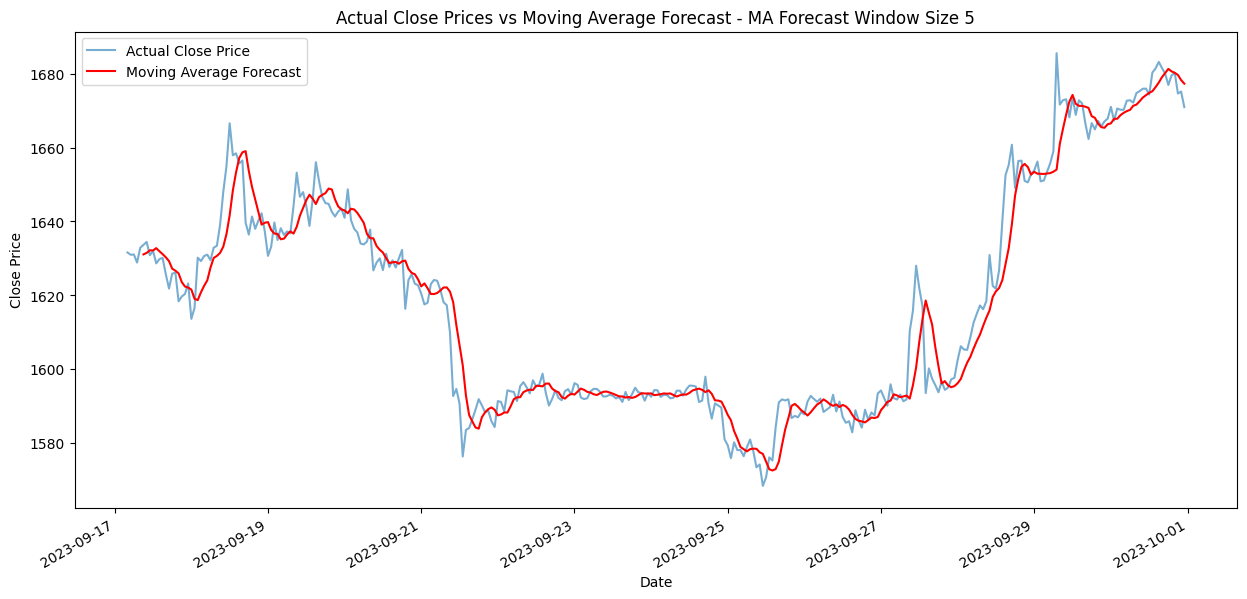

Timesteps: 327
Mean Squared Error (MSE): 46.54051924159022
Mean Absolute Error (MAE): 4.407730886850156
Root Mean Squared Error (RMSE): 6.822061216493899
Mean Absolute Percentage Error (MAPE): 0.2717557992257628%
R^2 Score: 0.9510265289993329
Explained Variance Score: 0.9511948416742987


In [26]:
import pandas as pd
import numpy as np
from sklearn.metrics import explained_variance_score, mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

test = pd.read_csv("ETHUSD_MA.csv")

# Choose a window size for the moving average
window_size = 5

# Calculate the moving average
test['moving_avg'] = test['close_price'].rolling(window=window_size).mean()

# The forecast for the next time step is the last value of the moving average
# Shift the moving average by 1 to align with the actual values for comparison
test['forecast'] = test['moving_avg'].shift(1)

# Evaluate the model on the portion of the dataset where moving average values are available
actual = test['close_price'][window_size:]  # Actual values, excluding the first few that don't have a moving average
forecast = test['forecast'][window_size:]  # Forecast values

mse_value = mean_squared_error(actual, forecast)
mae_value = mean_absolute_error(actual, forecast)
rmse_value = np.sqrt(mse_value)
mape_value = np.mean(np.abs((actual - forecast) / actual)) * 100
r2_value = r2_score(actual, forecast)
explained_variance = explained_variance_score(actual, forecast)

# Visualization
plt.figure(figsize=(15, 7))

test['bucket'] = pd.to_datetime(test['bucket'])

# Plotting the actual and forecasted values
plt.plot(test['bucket'], test['close_price'], label='Actual Close Price', alpha=0.6)
plt.plot(test['bucket'], test['forecast'], color='red', label='Moving Average Forecast')

# Format the date axis
ax = plt.gca()  # Get current axis
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # Automatically find the best location for ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format the ticks as year-month-day

plt.gcf().autofmt_xdate()  # Automatically format the x-axis dates to fit them better

plt.title('Actual Close Prices vs Moving Average Forecast - MA Forecast Window Size 5')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

print(f"Timesteps: {len(forecast)}") 
print(f"Mean Squared Error (MSE): {mse_value}")
print(f"Mean Absolute Error (MAE): {mae_value}")
print(f"Root Mean Squared Error (RMSE): {rmse_value}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_value}%")
print(f"R^2 Score: {r2_value}")
print(f"Explained Variance Score: {explained_variance}")

## Baseline: last value as forecast 


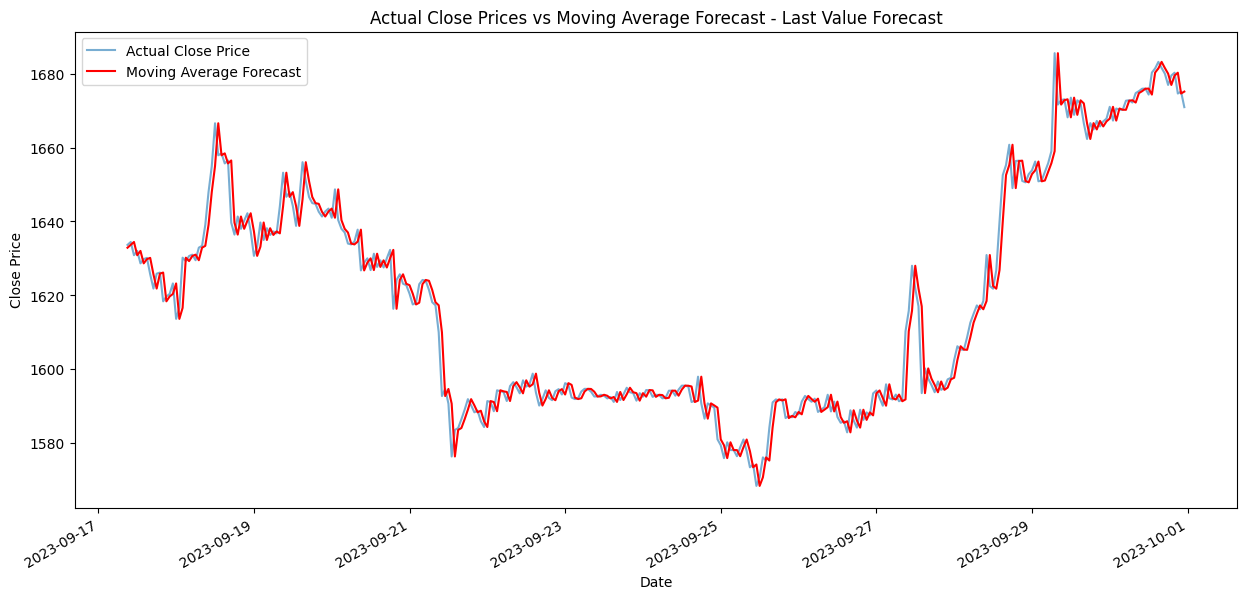

Timesteps: 327
Mean Squared Error (MSE): 23.523525688073466
Mean Absolute Error (MAE): 3.235749235474013
Root Mean Squared Error (RMSE): 4.850105739885829
Mean Absolute Percentage Error (MAPE): 0.19941091014044557%
R^2 Score: 0.9752467586977668
Explained Variance Score: 0.9752610663299439


In [25]:
# Making sure it uses the same amount of values
test = pd.read_csv("ETHUSD_MA.csv")
test = test.iloc[window_size-1:]

test['forecast_last_value'] = test['close_price'].shift(1)
test.dropna(inplace=True)

# Evaluate the model on the portion of the dataset where moving average values are available
actual = test['close_price']  # Actual values, excluding the first few that don't have a moving average
forecast = test['forecast_last_value']  # Forecast values

mse_value = mean_squared_error(actual, forecast)
mae_value = mean_absolute_error(actual, forecast)
rmse_value = np.sqrt(mse_value)
mape_value = np.mean(np.abs((actual - forecast) / actual)) * 100
r2_value = r2_score(actual, forecast)
explained_variance = explained_variance_score(actual, forecast)

# Visualization
plt.figure(figsize=(15, 7))

test['bucket'] = pd.to_datetime(test['bucket'])

# Plotting the actual and forecasted values
plt.plot(test['bucket'], test['close_price'], label='Actual Close Price', alpha=0.6)
plt.plot(test['bucket'], test['forecast_last_value'], color='red', label='Moving Average Forecast')

# Format the date axis
ax = plt.gca()  # Get current axis
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # Automatically find the best location for ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format the ticks as year-month-day

plt.gcf().autofmt_xdate()  # Automatically format the x-axis dates to fit them better

plt.title('Actual Close Prices vs Moving Average Forecast - Last Value Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


print(f"Timesteps: {len(test['forecast_last_value'])}") 
print(f"Mean Squared Error (MSE): {mse_value}")
print(f"Mean Absolute Error (MAE): {mae_value}")
print(f"Root Mean Squared Error (RMSE): {rmse_value}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_value}%")
print(f"R^2 Score: {r2_value}")
print(f"Explained Variance Score: {explained_variance}")